# SVI tests with Average DP Gaussian

Testing if we can use SVI with a more complicated function

In [1]:
# Imports
import math
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Anonymization function (Average DP Gaussian) - https://github.com/itu-square/privugger_benchmarks/blob/main/plain_python_code/average_dp_gaussian.py
def avg_dp_gaussian(dataset: list[float],
                    max_value_dataset_entry: float,
                    min_value_dataset_entry: float,
                    delta: float,
                    epsilon: float) -> float:
    avg   = sum(dataset)/len(dataset)
    sensitivity = (max_value_dataset_entry - min_value_dataset_entry)/len(dataset)
    noise_std = sensitivity*np.sqrt(2*np.log(1.25/delta))/epsilon
    noise = np.random.normal(loc=0,scale=noise_std)
    return avg + noise

In [3]:
dataset = [1,2,3,4,5]

print(f"Average: {sum(dataset)/len(dataset)}, DP Average: {avg_dp_gaussian(dataset, 5, 1, 0.1, 0.1)}")

Average: 3.0, DP Average: 13.545333084080612


In [4]:
def model_dp(
    size: int,
    target_prior: dist.Distribution,  # e.g., Uniform(0, 100)
    others_prior: dist.Distribution,  # e.g., Normal(20, 5)
    max_val: float,
    min_val: float,
    delta: float,
    epsilon: float,
    y_observed: float,
    observation_noise: float = 0.1  # small noise to mimic a delta function
):

    ### --- Generation of data used by the model

    # Sample the target individual's data (e.g., from Uniform(0,100))
    X_target = pyro.sample("X_target", target_prior)

    # Sample the other individuals: a vector of length (size - 1) from others_prior (e.g., Normal(20,5))
    others = pyro.sample("others", others_prior.expand([size - 1]).to_event(1))


    ### --- DP mechanism and likelihood (to be changed for every anonymization function)

    # Compute the aggregator (the average of the target and others)
    aggregator = (X_target + others.sum()) / size

    # Optionally, add DP noise
    # sensitivity = (max_val - min_val) / size
    # noise_std = sensitivity * math.sqrt(2.0 * math.log(1.25/delta)) / epsilon
    # dp_noise = pyro.sample("dp_noise", dist.Normal(torch.tensor(0.0), torch.tensor(noise_std)))
    # dp_result = aggregator + dp_noise

    # For now, we use the aggregator directly as the DP result
    dp_result = aggregator

    # Condition on the observed DP result using a small likelihood variance (spike-like posterior)
    pyro.sample("obs_dp_result",
                dist.Normal(dp_result, observation_noise),
                obs=torch.tensor(y_observed))

    return dp_result

In [5]:
def guide_dp(
    size: int,  # total dataset size (target + others)
    target_prior: dist.Distribution,  # e.g., Uniform(0, 100) or Normal(...)
    others_prior: dist.Distribution,  # provided for the model (not used in the guide)
    max_val: float,
    min_val: float,
    delta: float,
    epsilon: float,
    y_observed: float,
    observation_noise: float
):
    """
    Guide for SVI:
      - Learn an approximate posterior for the target individual's data (X_target)
      - We use a simple Normal distribution parameterized by a learnable mean and standard deviation.
    """
    # Initialize parameters based on the target_prior type.
    if isinstance(target_prior, dist.Uniform):
        # For Uniform, we initialize at the midpoint and choose a small std relative to the range.
        target_init = ((target_prior.low + target_prior.high) / 2.0).item()
        init_std = ((target_prior.high - target_prior.low) / 10.0).item()
    elif isinstance(target_prior, dist.Normal):
        target_init = target_prior.mean.item()
        init_std = target_prior.stddev.item()
    else:
        target_init = (min_val + max_val) / 2.0
        init_std = (max_val - min_val) / 10.0

    # Define the learnable parameters for the target's posterior.
    mu_target = pyro.param("mu_target", torch.tensor(target_init, dtype=torch.float))
    std_target = pyro.param("std_target", torch.tensor(init_std, dtype=torch.float),
                              constraint=dist.constraints.interval(min_val, max_val))

    # Sample the target individual's data from the learned approximate posterior.
    pyro.sample("X_target", dist.Normal(mu_target, std_target))


In [6]:
# QIF HELPER FUNCTIONS: ENTROPY, KL DIVERGENCE, ETC.

def normal_entropy(std: float) -> float:
    """
    Differential entropy of a 1D Normal(?, std^2).
    H = 0.5 * ln(2 * pi * e * std^2).
    Returns in NATS by default.
    """
    return 0.5 * math.log(2.0 * math.pi * math.e * (std**2))

def kl_divergence_normals(mean_p, std_p, mean_q, std_q) -> float:
    """
    KL( N(mean_p, std_p^2) || N(mean_q, std_q^2) ), in NATS.
    Formula: ln(std_q/std_p) + (std_p^2 + (mean_p - mean_q)^2)/(2 std_q^2) - 1/2
    """
    ratio = std_q / std_p
    t1 = math.log(ratio)
    t2 = (std_p**2 + (mean_p - mean_q)**2) / (2.0 * std_q**2)
    return t1 + t2 - 0.5

In [8]:
# PLOTTING PRIOR & POSTERIOR
def plot_prior_posterior_target(target_prior, post_mean, post_std):
    """
    Plot prior vs. posterior distributions as curves.
    Handles different types of priors (e.g., Uniform, Normal).
    """
    # Determine plotting range based on the prior type
    if isinstance(target_prior, dist.Uniform):
        x_min, x_max = target_prior.low.item(), target_prior.high.item()
        xs = np.linspace(x_min, x_max, 200)
        prior_pdf = np.ones_like(xs) / (x_max - x_min)  # Uniform PDF
    elif isinstance(target_prior, dist.Normal):
        x_min = target_prior.mean.item() - 3 * target_prior.stddev.item()
        x_max = target_prior.mean.item() + 3 * target_prior.stddev.item()
        xs = np.linspace(x_min, x_max, 200)
        prior_pdf = (1.0 / (target_prior.stddev.item() * np.sqrt(2.0 * np.pi))
                     * np.exp(-0.5 * ((xs - target_prior.mean.item()) / target_prior.stddev.item())**2))
    else:
        raise ValueError("Unsupported prior distribution type for plotting.")

    # Compute posterior PDF (assumed to be Gaussian)
    post_pdf = (1.0 / (post_std * np.sqrt(2.0 * np.pi))
                * np.exp(-0.5 * ((xs - post_mean) / post_std)**2))

    # Plot the prior and posterior distributions
    plt.figure(figsize=(7, 4))
    plt.plot(xs, prior_pdf, label='Prior', linestyle='dashed')
    plt.plot(xs, post_pdf, label='Posterior', linewidth=2)
    plt.title("Attacker's Belief of Victim's Data: Prior vs. Posterior")
    plt.xlabel("Value of X_target")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_loss_curve(losses):
    """
    Plots the loss curve using iteration numbers from the collected losses list.
    """
    iterations, loss_values = zip(*losses)  # Unzip the tuple list into two lists

    plt.figure(figsize=(8, 5))
    plt.plot(iterations, loss_values, label="Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("SVI Training Loss")
    plt.legend()
    plt.grid()
    plt.show()

The Attacker observation is: 21.3
iter 0 | loss = 12907739.57221508
iter 500 | loss = 6276022.102750778
iter 1000 | loss = 2125783.6472878456
iter 1500 | loss = 33305.55406546593
iter 2000 | loss = 225561.22038316727
iter 2500 | loss = 1554337.493039608
iter 3000 | loss = 1502391.3527839184
iter 3500 | loss = 1107947.5920455456
iter 4000 | loss = 155357.92756658792
iter 4500 | loss = 5923.874049603939

--- Results ---
Target Prior: Uniform(low: 0.0, high: 100.0)
Posterior for Target -> N(29.68, 0.67)


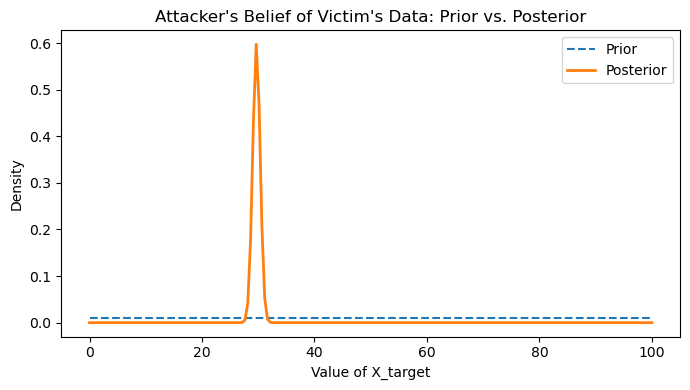

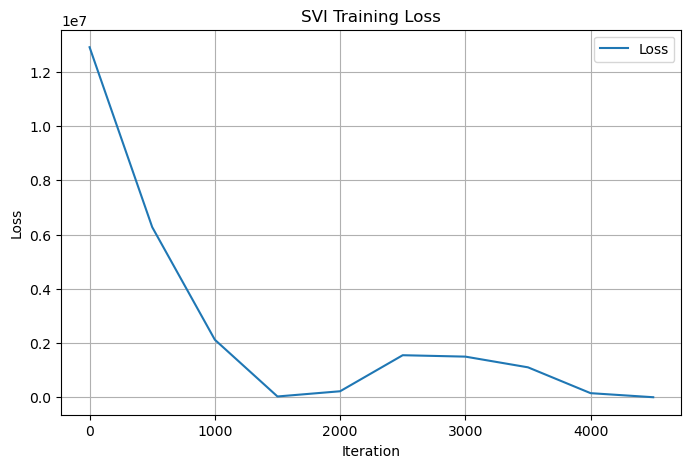

--- QIF / Info measures ---
Prior entropy (nats):      4.6052
Posterior entropy (nats):  1.0138
Info gain  (nats):         3.5913   (bits: 5.1812)


In [22]:

def default_run():
    # Define the dataset size: 1 target individual + 6 others = 7
    dataset_size = 7

    # Define the target prior (e.g., Uniform over [0,100]) and the others prior (e.g., Normal(20,5))
    target_prior = dist.Uniform(torch.tensor(0.0), torch.tensor(100.0))
    others_prior = dist.Normal(torch.tensor(20.0), torch.tensor(5.0))

    # DP hyperparameters (using a domain that fits the target's prior)
    max_val = 100.0
    min_val = 0.0
    delta   = 1e-5
    epsilon = 10  # Lower anonymity

    # The attacker sees a final DP output (manual input)
    y_observed = 21.3
    print(f"The Attacker observation is: {y_observed}")

    # Build the SVI using the updated model and guide
    pyro.clear_param_store()
    svi = SVI(model_dp, guide_dp,
              Adam({"lr": 0.01}),
                  loss=Trace_ELBO())

    # Train SVI
    losses = []
    num_steps = 5000
    for step in range(num_steps):
        loss = svi.step(dataset_size, target_prior, others_prior,
                        max_val, min_val, delta, epsilon,
                        y_observed, 0.001)
        if step % 500 == 0:
            print(f"iter {step} | loss = {loss}")
            losses.append((step, loss))

    # Retrieve the learned posterior parameters for the target individual
    post_mean = pyro.param("mu_target").item()
    post_std = pyro.param("std_target").item()

    print("\n--- Results ---")
    print(f"Target Prior: {target_prior}")
    print(f"Posterior for Target -> N({post_mean:.2f}, {post_std:.2f})")

    # Plot prior vs. posterior (using a helper that accepts the target prior and learned posterior)
    plot_prior_posterior_target(target_prior, post_mean, post_std)
    plot_loss_curve(losses)

    # QIF metrics:
    # For a Uniform prior U(min_val, max_val), the entropy is log(max_val - min_val)
    prior_ent = math.log(max_val - min_val)
    post_ent = normal_entropy(post_std)
    info_gain = prior_ent - post_ent
    info_gain_bits = info_gain / math.log(2.0)

    print("--- QIF / Info measures ---")
    print(f"Prior entropy (nats):      {prior_ent:.4f}")
    print(f"Posterior entropy (nats):  {post_ent:.4f}")
    print(f"Info gain  (nats):         {info_gain:.4f}   (bits: {info_gain_bits:.4f})")

default_run()

In [27]:
from tqdm.notebook import tqdm

def run_svi_once(num_steps=5000, lr=1e-2):
    """
    Runs one SVI training and returns an array of losses (length num_steps).
    This duplicates your default_run logic but stores the loss at every step.
    """
    # Define dataset size: 1 target + 6 others = 7 total individuals.
    dataset_size = 7

    # Define the priors:
    # Target prior: e.g., Uniform over [0, 100]
    target_prior = dist.Uniform(torch.tensor(0.0), torch.tensor(100.0))
    # Others prior: e.g., Normal with mean 10 and std 5
    others_prior = dist.Normal(torch.tensor(20.0), torch.tensor(5.0))

    # DP hyperparameters
    max_val = 100.0
    min_val = 0.0
    delta   = 1e-5
    epsilon = 10 # Low privacy

    # Simulate a DP output (y_observed):
    # Sample a target and others from the priors.
    sample_target = target_prior.sample()
    sample_others = others_prior.sample([dataset_size - 1])
    # Compute the aggregator (average of target and others)
    aggregator = (sample_target + sample_others.sum()) / dataset_size
    # Add a small noise to simulate DP noise
    noise = dist.Normal(0.0, 0.1).sample()
    y_observed = aggregator + noise

    print(f"The Attacker observation is: {y_observed.item()}")

    pyro.clear_param_store()
    svi = SVI(
        model_dp,
        guide_dp,
        Adam({"lr": lr}),
        loss=Trace_ELBO()
    )

    losses = []
    for step in range(num_steps):
        loss = svi.step(
            dataset_size, target_prior, others_prior,
            max_val, min_val, delta, epsilon,
            y_observed, 0.001  # Pass observation_noise = 0.1
        )
        losses.append(loss)

    return np.array(losses)


def multiple_runs_experiment(n_runs=30, num_steps=5000, lr=1e-2, plot_interval=500):
    """
    Runs the SVI training n_runs times, collects per-iteration losses,
    and plots min/mean/max/std across runs at defined intervals.
    """
    all_losses = []

    for run in tqdm(range(n_runs), desc="Running SVI experiments"):
        run_losses = run_svi_once(num_steps=num_steps, lr=lr)
        all_losses.append(run_losses)

    # Convert to a 2D array of shape (n_runs, num_steps)
    all_losses = np.stack(all_losses, axis=0)  # shape = [n_runs, num_steps]

    # Compute statistics across runs at each iteration
    mean_loss = np.mean(all_losses, axis=0)
    std_loss  = np.std(all_losses, axis=0)
    min_loss  = np.min(all_losses, axis=0)
    max_loss  = np.max(all_losses, axis=0)

    # Select only every `plot_interval` iterations for visualization
    selected_indices = np.arange(0, num_steps, plot_interval)

    mean_selected = mean_loss[selected_indices]
    std_selected = std_loss[selected_indices]
    min_selected = min_loss[selected_indices]
    max_selected = max_loss[selected_indices]

    # Plot
    plt.figure(figsize=(8, 5))

    # Mean loss as points with error bars (std deviation)
    plt.errorbar(
        selected_indices, mean_selected, yerr=std_selected, fmt='o-', color="blue",
        label="Mean loss (± std dev)", capsize=4
    )

    # Shaded area for min-max range
    plt.fill_between(selected_indices, min_selected, max_selected, alpha=0.2, color="gray", label="Min/Max range")

    plt.xlabel("Iteration")
    plt.ylabel("SVI Loss (negative ELBO)")
    plt.title(f"Loss Trends Over {n_runs} Runs (each {num_steps} steps, lr={lr})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Print stats at key iterations
    print("\nFinal Loss Statistics at Key Iterations:")
    for it in selected_indices:
        print(f"Iteration {it:4d} | Mean: {mean_loss[it]:.4f}, Std: {std_loss[it]:.4f}, Min: {min_loss[it]:.4f}, Max: {max_loss[it]:.4f}")

Running SVI experiments:   0%|          | 0/10 [00:00<?, ?it/s]

The Attacker observation is: 21.331445693969727


C:\Users\tommc\AppData\Local\Temp\ipykernel_397624\4016310572.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  obs=torch.tensor(y_observed))


The Attacker observation is: 30.944332122802734
The Attacker observation is: 31.776227951049805
The Attacker observation is: 28.58287239074707
The Attacker observation is: 27.036983489990234
The Attacker observation is: 28.054616928100586
The Attacker observation is: 19.56461524963379
The Attacker observation is: 24.032201766967773
The Attacker observation is: 27.337024688720703
The Attacker observation is: 22.73184585571289


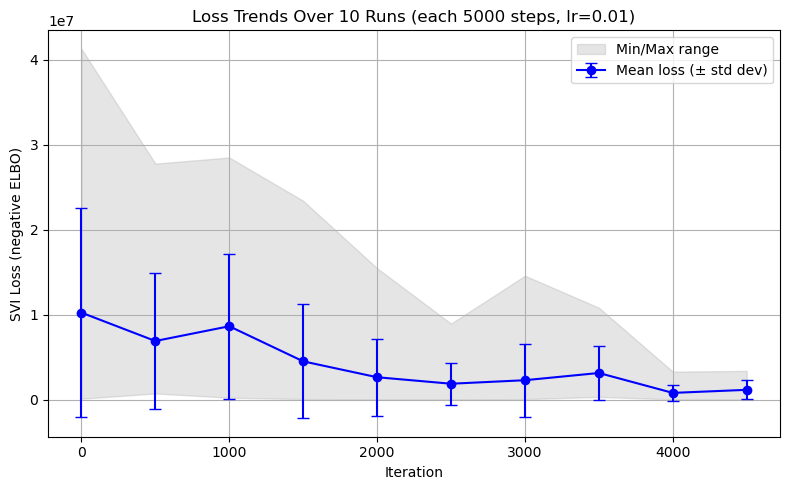


Final Loss Statistics at Key Iterations:
Iteration    0 | Mean: 10222754.2346, Std: 12261857.5297, Min: 90610.3595, Max: 41260377.5177
Iteration  500 | Mean: 6882374.5894, Std: 8015821.5010, Min: 709257.3059, Max: 27753868.8540
Iteration 1000 | Mean: 8620229.8898, Std: 8514769.1076, Min: 213308.9724, Max: 28474979.7879
Iteration 1500 | Mean: 4490096.3595, Std: 6694382.6952, Min: 46967.7224, Max: 23378958.7710
Iteration 2000 | Mean: 2621086.5647, Std: 4536040.7772, Min: 23575.2748, Max: 15446497.4785
Iteration 2500 | Mean: 1857323.2051, Std: 2467994.8302, Min: 23456.6994, Max: 8931582.3894
Iteration 3000 | Mean: 2270437.9766, Std: 4268871.1252, Min: 41415.4348, Max: 14562848.4488
Iteration 3500 | Mean: 3120603.5734, Std: 3227647.7007, Min: 302774.4098, Max: 10803164.9366
Iteration 4000 | Mean: 778908.3097, Std: 965012.5818, Min: 15528.9402, Max: 3282131.6686
Iteration 4500 | Mean: 1138653.8273, Std: 1136922.6709, Min: 3426.0855, Max: 3368260.9501


In [28]:
multiple_runs_experiment(n_runs=10, num_steps=5000, lr=1e-2, plot_interval=500)